# CMSE 381 Final Project Template

#### CMSE 381 Final Project
### &#9989; Group members: Mint Menakanit, Brian Kim
### &#9989; Section_001
#### &#9989; Date

# ___Student Exam Score___

## Background and Motivation

_(Provide context for the problem.  **Clearly state the question(s) you set
out to answer.**)_
Understanding what factors drive academic success.
Questions that we want to answer in this report
1. Can we accurately predict student's exams score from 19 available predictors and which one matters the most?
2. Do lasso and ridge regression outperform OLS and effectively produce auto features selection?
3. Can we compress the predictor space into a small number of principal components without losing predictive power and what do those components represent?

## Methodology
_(How did you go about answering your question(s)? You should wrote some code here to demonstrate what the data is like and how in principle your method works. You can leave the variations of the related to specific results to the results section.)_

1. Data loading
2. Data cleaning / preprocessing : there are missing values and some features need scaling
3. Classification
4. Regression :
- we do OLS multiple linear regression with K-fold cross validation
- improve regression with regularization
  - Ridge / Lasso : first we do parameter selection with cross validation and then do subset selection with built in sparse feature
  - PCA : reduce full feature matrix to principal components and evaluate how many PCs are needed with cross-validated PC count selection

In [3]:
# you may want to import some modules here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# regression
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso

# PCA
from sklearn.decomposition import PCA

# CV and metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(381)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

### Data
_(Describe the data you are using. What variables are you using? What they mean? Why did you choose them?)_

In [6]:
# you may want to write some code to see what the data looks like
df = pd.read_csv("Student_Performance_Factors.csv")
print(df.shape)
df.head()

# 6607 dataset
# 20 columns : 19 features 1 target (exam score)

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# you may need some code here to adjust the format or organization of your data so that they can be used for the model

In [9]:
# check for null value
print(df.isnull().sum()[df.isnull().sum() > 0])

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


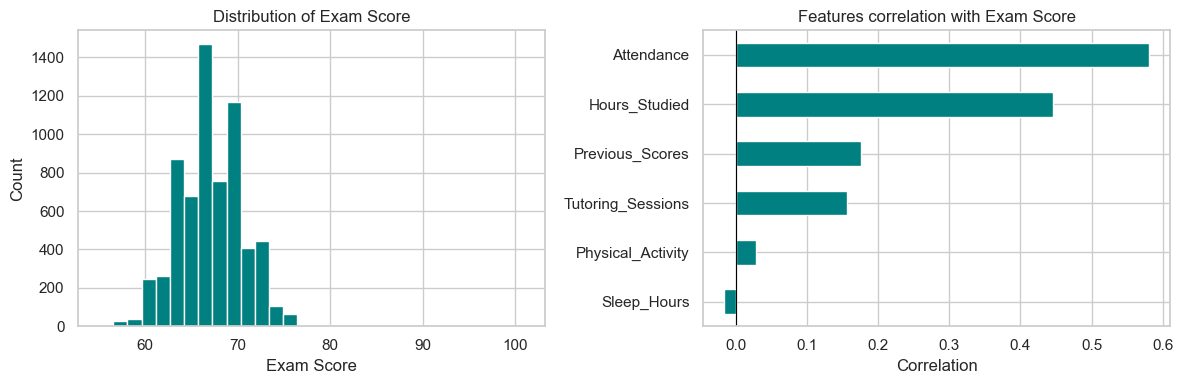

Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Exam_Score"], bins = 30, edgecolor = "white", color = "teal")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Exam Score")

num_cols = df.select_dtypes(include = "number").columns
corr = df[num_cols].corr()["Exam_Score"].drop("Exam_Score").sort_values()
corr.plot(kind = "barh", ax = axes[1], color = "teal")
axes[1].set_title("Features correlation with Exam Score")
axes[1].set_xlabel("Correlation")
axes[1].axvline(0, color = "black", linewidth = 0.8)

plt.tight_layout()
plt.show()

print(corr.sort_values(ascending = False))

### Models for classification _(if applicable)_
_(What models will you be using for classification? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

In [ ]:
# you may add some code here to show how the model works in principle

### Models for regression _(if applicable)_
_(What models will you be using for regression? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

In [15]:
# you may add some code here to show how the model works in principle
kf = KFold(n_splits = 10, shuffle = True, random_state = 381)
ols = LinearRegression()

cv_r2  = cross_val_score(ols, X, y, cv = kf, scoring = "r2")
cv_mse = cross_val_score(ols, X, y, cv = kf, scoring = "neg_mean_squared_error")
cv_rmse = np.sqrt(-cv_mse)

print("Mean R squared :", cv_r2.mean())
print("Mean RMSE :", cv_rmse.mean())

Mean R squared : 0.7320835002853239
Mean RMSE : 2.0007878971095545


In [17]:
# Fit on full data
ols.fit(X, y)
coef_df = pd.DataFrame({ "Feature": feature_cols,
                         "Coefficient": ols.coef_
                       }).sort_values("Coefficient", key = abs, ascending = False)
print(coef_df.head(10).to_string(index = False))

                 Feature  Coefficient
              Attendance     2.296538
           Hours_Studied     1.766396
     Access_to_Resources     0.716066
         Previous_Scores     0.704120
    Parental_Involvement     0.692732
       Tutoring_Sessions     0.611948
           Family_Income     0.394808
          Peer_Influence     0.388243
Parental_Education_Level     0.379967
        Motivation_Level     0.368391


### Other methods used _(if applicable)_

_(If this is a preprocessing step to prepare your data for regression or classification models, you should put this subsection before your explanation for the regression or classification models.)_

_(What method did you use otherwise? Why did you choose to use them? What questions would you answer with them? How would you evaluate the results? What cross-validation method did you use when applicable?)_

In [10]:
# fill out null value
df_1 = df.copy()
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    df_1[col] = df[col].fillna(df[col].mode()[0])
print(df_1.isnull().sum()[df_1.isnull().sum() > 0])

Series([], dtype: int64)


In [11]:
# Encode category to binary
ordinal_maps = {
    "Parental_Involvement":    {"Low": 0, "Medium": 1, "High": 2},
    "Access_to_Resources":     {"Low": 0, "Medium": 1, "High": 2},
    "Motivation_Level":        {"Low": 0, "Medium": 1, "High": 2},
    "Family_Income":           {"Low": 0, "Medium": 1, "High": 2},
    "Teacher_Quality":         {"Low": 0, "Medium": 1, "High": 2},
    "Parental_Education_Level":{"High School": 0, "College": 1, "Postgraduate": 2},
    "Distance_from_Home":      {"Near": 0, "Moderate": 1, "Far": 2},
    "Peer_Influence":          {"Negative": 0, "Neutral": 1, "Positive": 2},
}
for col, mapping in ordinal_maps.items():
    df_1[col] = df_1[col].map(mapping)

binary_maps = {
    "Extracurricular_Activities": {"No": 0, "Yes": 1},
    "Internet_Access":            {"No": 0, "Yes": 1},
    "School_Type":                {"Public": 0, "Private": 1},
    "Learning_Disabilities":      {"No": 0, "Yes": 1},
    "Gender":                     {"Male": 0, "Female": 1},
}
for col, mapping in binary_maps.items():
    df_1[col] = df_1[col].map(mapping)

In [12]:
# Build X and y
feature_cols = [c for c in df_1.columns if c != "Exam_Score"]
X_raw = df_1[feature_cols].values.astype(float)
y = df_1["Exam_Score"].values.astype(float)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(X.shape, y.shape)

(6607, 19) (6607,)


In [ ]:
# you may add some code here to show how the method works in principle

# you may add some code here to show how the model works in principle

## Results

_(What did you find when you carried out your methods? Some of your code related to
presenting results/figures/data may be replicated from the methods section or may only be present in
this section. All of the plots that you plan on using for your presentation should be present in this
section)_

### classification results
_(What are you trying to do here?)_

In [ ]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [ ]:
# how did you do it (etc. etc.)

### regression results
_(What are you trying to do here?)_

In [ ]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [ ]:
# how did you do it (etc. etc.)

### other results
_(What are you trying to do here?)_

In [ ]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [ ]:
# how did you do it (etc. etc.)

## Discussion and Conclusion

_(What did you learn from your results? What obstacles did you run into? What would you do differently next time? Clearly provide quantitative answers to your question(s)?  At least one of your questions should be answered with numbers.  That is, it is not sufficient to answer "yes" or "no", but rather to say something quantitative such as variable 1 increased roughly 10% for every 1 year increase in variable 2.)_

### discussion on the classification results

### discussion on the regression results

### discussion on the other results

### conclusion and future steps

## Author contribution

_(Please describe the contribution of each member of group)._

## References

_(List the source(s) for any data and/or literature cited in your project.  Ideally, this should be formatted using a formal citation format (MLA or APA or other, your choice!).   Multiple free online citation generators are available such as <a href="http://www.easybib.com/style">http://www.easybib.com/style</a>. **Important:** if you use **any** code that you find on the internet for your project you **must** cite it or you risk losing most/all of the points for you project.)_